# Verify Trial Structure
Split out from `03_psth_raster_NWB_testing.ipynb`. This notebook keeps the trial and event timing checks together.

In [23]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
%load_ext autoreload
%autoreload 2

import load_nwb
from load_nwb import nwb_loader
import nwb_data_prep as nwb_prep
import pca_data_prep as prep
import prep_data as data_prep
import PSTH_raster as psth_raster
import verify_data as verify

prep = importlib.reload(prep)
nwb_prep = importlib.reload(nwb_prep)
data_prep = importlib.reload(data_prep)
psth_raster = importlib.reload(psth_raster)
verify = importlib.reload(verify)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Session From `.env`

In [24]:
session_data_dic = prep.load_env()
session_data_dic

MOUSE loaded: Reach15




-- Behavioral Files --
BEHAVIORAL_FOLDER loaded: grant_reach15_swingDoor-christie
-- First Neuropixels File --
NP_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE loaded: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE loaded: 20260129
SESSION loaded: session003
BOMBCELL loaded: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG loaded: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG loaded: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG loaded: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json


-- Second Neuropixels File --
NP_FILE loaded: Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32
NWB_FILE loaded: NA
DATE_01 loaded: 20260129
SESSION_01 loaded: session004
BOMBCELL_01 loaded: NA
PROBE_A_CH_CONFIG_01 loaded: NA
PROBE_C_CH_CONFIG_01 loaded: NA
PROBE_D_CH_CONFIG_01 loa

{'MOUSE': 'Reach15',
 'BEHAVIORAL_FOLDER': 'grant_reach15_swingDoor-christie',
 'NP_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'DATE': '20260129',
 'SESSION': 'session003',
 'BOMBCELL': 'bombcell_batch_20260305_1130',
 'NWB_FILE': 'Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01',
 'PROBE_A_CH_CONFIG': 'probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_C_CH_CONFIG': 'probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'PROBE_D_CH_CONFIG': 'probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json',
 'NP_FILE_01': 'Reach15_20260129_session004_NP_Recording_02_2026-01-29_16-50-32',
 'DATE_01': '20260129',
 'SESSION_01': 'session004',
 'BOMBCELL_01': 'NA',
 'NWB_FILE_01': 'NA',
 'PROBE_A_CH_CONFIG_01': 'NA',
 'PROBE_C_CH_CONFIG_01': 'NA',
 'PROBE_D_CH_CONFIG_01': 'NA',
 'NP_FILE_02': 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00',
 'DA

In [25]:
SESSION_TO_ANALYZE = 1

MOUSE, BEHAVIORAL_FOLDER, PROBE_A_CH_CONFIG, PROBE_C_CH_CONFIG, PROBE_D_CH_CONFIG, NP_FILE, NWB_FILE, DATE, SESSION, BOMBCELL = prep.session_to_analyze(
    session_data_dic['MOUSE'],
    session_data_dic['BEHAVIORAL_FOLDER'],
    session_data_dic['NP_FILE'],
    session_data_dic['NWB_FILE'],
    session_data_dic['DATE'],
    session_data_dic['SESSION'],
    session_data_dic['BOMBCELL'],
    session_data_dic['PROBE_A_CH_CONFIG'],
    session_data_dic['PROBE_C_CH_CONFIG'],
    session_data_dic['PROBE_D_CH_CONFIG'],
    session_data_dic['NP_FILE_01'],
    session_data_dic['NWB_FILE_01'],
    session_data_dic['DATE_01'],
    session_data_dic['SESSION_01'],
    session_data_dic['BOMBCELL_01'],
    session_data_dic['PROBE_A_CH_CONFIG_01'],
    session_data_dic['PROBE_C_CH_CONFIG_01'],
    session_data_dic['PROBE_D_CH_CONFIG_01'],
    session_data_dic['NP_FILE_02'],
    session_data_dic['NWB_FILE_02'],
    session_data_dic['DATE_02'],
    session_data_dic['SESSION_02'],
    session_data_dic['BOMBCELL_02'],
    session_data_dic['PROBE_A_CH_CONFIG_02'],
    session_data_dic['PROBE_C_CH_CONFIG_02'],
    session_data_dic['PROBE_D_CH_CONFIG_02'],
    session_selection=SESSION_TO_ANALYZE,
)

PROBES = ['A', 'B', 'C', 'D', 'E', 'F']
paths_dic = prep.setup_paths_and_verify(PROBES, NWB_FILE, NP_FILE, DATE, SESSION, BEHAVIORAL_FOLDER, BOMBCELL)
paths_dic


SESSION SELECTION:

NP_FILE: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
NWB_FILE: Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01
DATE: 20260129
SESSION: session003
BEHAVIORAL_FOLDER: grant_reach15_swingDoor-christie
BOMBCELL: bombcell_batch_20260305_1130
PROBE_A_CH_CONFIG: probeA_SIM_IP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_C_CH_CONFIG: probeC_MoP__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
PROBE_D_CH_CONFIG: probeD_VaL__Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01.json
✅ Found bombcell data for probe A at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_A
✅ Found bombcell data for probe B at H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01\bombcell\bombcell_batch_20260305_1130\kilosort4_B
✅ Found bombcell data for probe C at H:\

{'NP_ROOT_DIR': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01'),
 'NWB_PATH': WindowsPath('H:/NWB_OUT/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01'),
 'BOMBCELL_ROOT_FOR_AUTO_BUILD': WindowsPath('H:/Grant/Neuropixels/Kilosort_Recordings/Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01/bombcell/bombcell_batch_20260305_1130'),
 'baseline_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260129\\christielab\\session003\\20260129_christielab_session003_baseline_trial_numbers_tone2_aligned.npy',
 'washout_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260129\\christielab\\session003\\20260129_christielab_session003_washout_trial_numbers_tone2_aligned.npy',
 'optoicalStim_trials_index_path': 'G:\\Grant\\behavior_data\\DLC_net\\grant_reach15_swingDoor-christie\\videos\\20260129\\christielab\\sess

## Load NWB, Processed Bundle, and Event Arrays

In [26]:
mouse_nwb = paths_dic['NWB_PATH']
baseline_trials_index_path = paths_dic['baseline_trials_index_path']
washout_trials_index_path = paths_dic['washout_trials_index_path']
optoicalStim_trials_index_path = paths_dic['optoicalStim_trials_index_path']
BOMBCELL_ROOT_FOR_AUTO_BUILD = paths_dic['BOMBCELL_ROOT_FOR_AUTO_BUILD']

mouse_id = load_nwb.nwb_loader(mouse_nwb)
df_stim, df_units = nwb_loader.verify_nwb_data(mouse_id)

PROCESSED_BUNDLE_SESSION_DIR = Path.cwd().resolve() / 'processed_data' / NP_FILE
PROCESSED_BUNDLE_SESSION_DIR.mkdir(parents=True, exist_ok=True)

bundle, merged_dic, stim_df, df_stim, pca_event_meta_bundle, extras, meta, PROCESSED_BUNDLE_DIR = nwb_prep.load_or_build_processed_bundle(
    processed_bundle_dir=PROCESSED_BUNDLE_SESSION_DIR,
    nwb_path_for_auto_build=mouse_nwb,
    bombcell_root_for_auto_build=BOMBCELL_ROOT_FOR_AUTO_BUILD,
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=('merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl'),
    verbose=True,
)

baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

tone1_start_times, tone2_start_times, frame_events_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = data_prep.extract_start_times(df_stim)
(
    total_optical_timestamps,
    total_optoTagging_timestamps,
    total_opto_tagging_events,
    total_opto_tagging_pulses,
    first_opto_tagging_timestamp,
    end_opto_tagging_index,
    last_tone2_time,
    start_of_opto_tagging_index,
    behavioral_video_duration,
    final_behavioral_video_time,
    opto_closed_loop_start_timestamps,
    opto_tag_start_timestamps,
    last_closed_loop_start_time,
    first_opto_tagging_timestamp_per_trial,
    first_optical_pulse_per_closed_loop,
) = data_prep.seperate_closedLoop_optoTagging(
    optical_start_times,
    tone2_start_times,
    frame_events_start_times,
    total_opto_tagging_events=60,
    pulses_per_event=10,
)

pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times, baseline_reachInit_stimROI_start_times, stimulation_reachInit_stimROI_start_times, washout_reachInit_stimROI_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx,
)

EVENT_TIME_ALIGN_TO = 'all_stimROI_triggers_start_times'
pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    baseline_reachInit_stimROI_start_times=baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times=stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times=washout_reachInit_stimROI_start_times,
    custom_event_start_times=None,
    mismatch='index_then_nearest',
    max_delta_s=None,
    drop_unmatched=True,
)

verification_output_dir = Path.cwd().resolve() / 'processed_data' / NP_FILE / 'verification'
verification_output_dir.mkdir(parents=True, exist_ok=True)

loaded NWB from: H:\NWB_OUT\Reach15_20260129_session003_NP_Recording_2026-01-29_14-30-01

===== Total units Per Probe ====
A:  705
B:  531
C:  689
D:  901
E:  966
F:  1486

 ======= Unique stimulus types ==========   : 
 ['tone1_timestamps' 'tone2_timestamps' 'stimROI_timestamps'
 'frame_events_timestamp' 'optical_timestamps'
 'reachInit_stimROI_timestamps' 'opto_tagging_timestamps'
 'baseline_reachInit_stimROI_timestamps'
 'stimulation_reachInit_stimROI_timestamps'
 'washout_reachInit_stimROI_timestamps']

===== Total Timestamps Per Event ====
tone1_timestamps:  252
tone2_timestamps:  204
stimROI_timestamps:  78
frame_events_timestamp:  1080710
optical_timestamps:  1380
reachInit_stimROI_timestamps:  204
opto_tagging_timestamps:  60
baseline_reachInit_stimROI_timestamps:  20
stimulation_reachInit_stimROI_timestamps:  78
washout_reachInit_stimROI_timestamps:  105


Loaded bundle: C:\Users\user\Documents\github\NWB_and_Reaching_analysis\mice\Reach15\analyze_data\processed_data\Reach15_2

## Core Verification Checks

In [27]:
verify_result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    show_plot=False,
    verbose=True,
)
stim_timing_dic = verify.check_stim_event_timing(df_stim, max_window=4, show_detailed_output=True)
verify_result

Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [[21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
 [61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80]
 [101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118
  119 120]
 [141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158
  159 160]
 [181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
  199 200]]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100])
 list([121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140])
 list([161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180])
 list([201, 202, 

{'ok': False,
 'errors': ['Wash epoch 5 size = 4 (expected 20).'],
 'warnings': [],
 'used_epochs': {'baseline': array([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20]], dtype=object),
  'stim': array([[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
          37, 38, 39, 40],
         [61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76,
          77, 78, 79, 80],
         [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
          114, 115, 116, 117, 118, 119, 120],
         [141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
          154, 155, 156, 157, 158, 159, 160],
         [181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
          194, 195, 196, 197, 198, 199, 200]], dtype=object),
  'wash': array([list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]),
         list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 

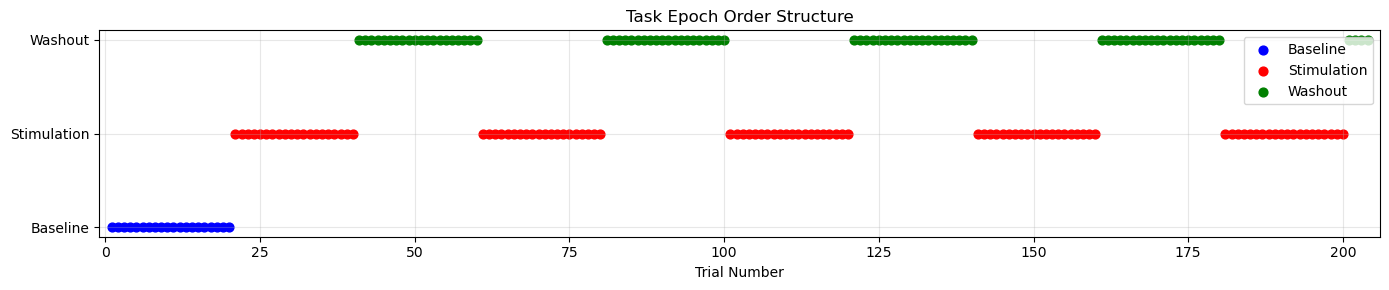

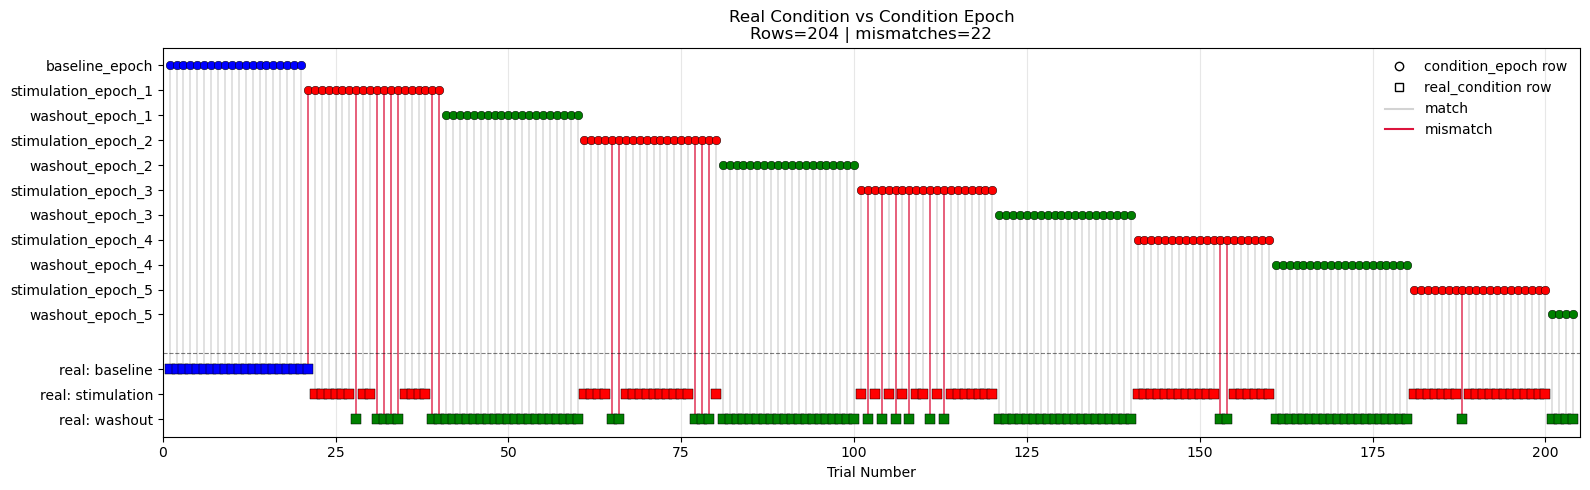

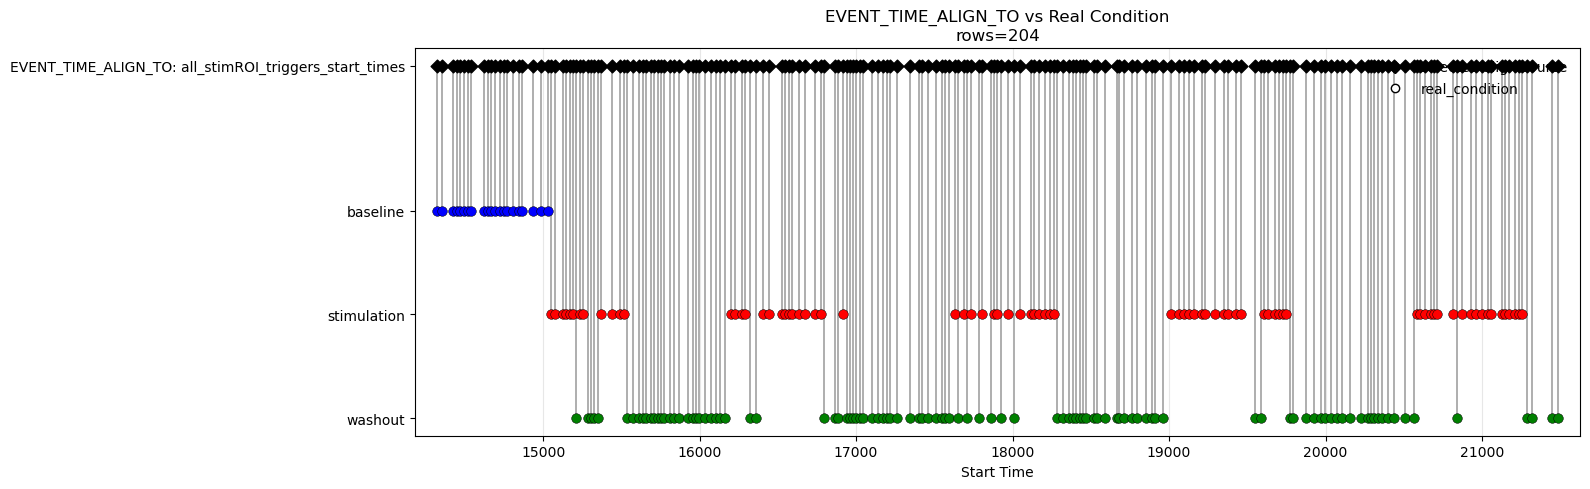

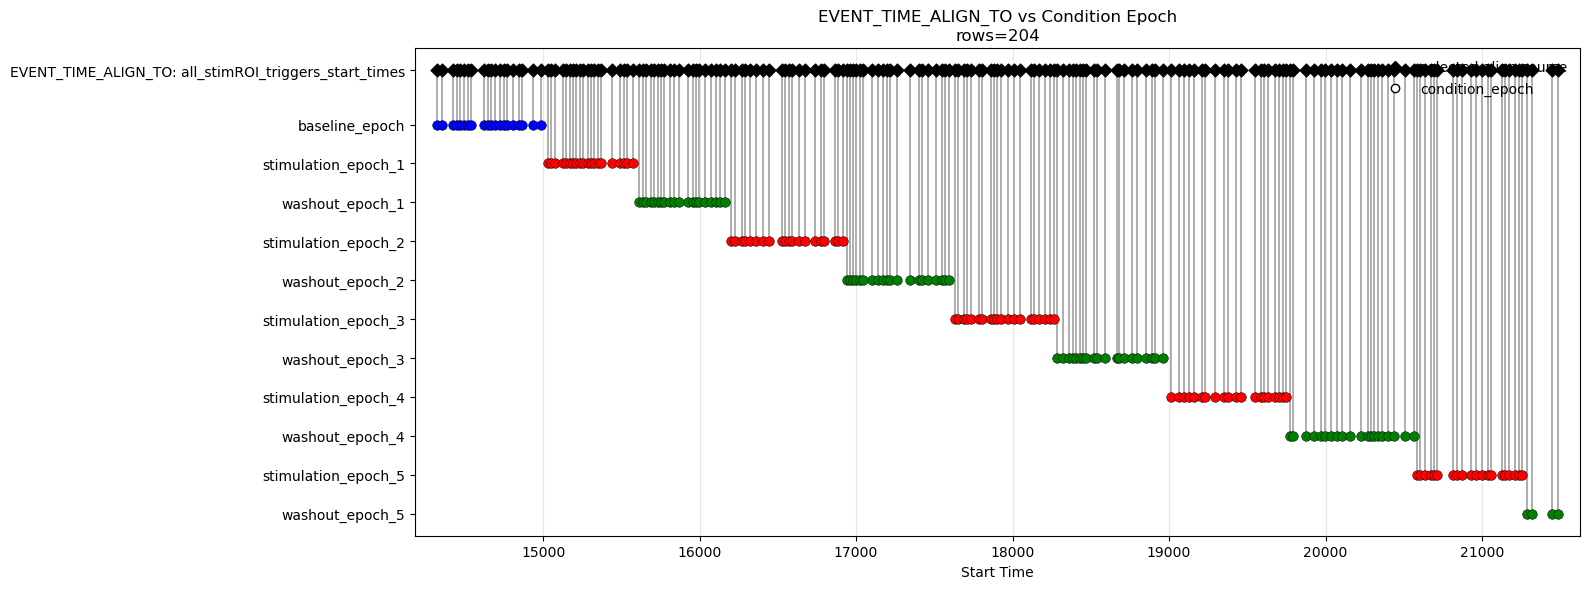

In [28]:
verify.plot_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_are_one_based=True,
    figsize=(14, 3),
)

verify.plot_real_condition_vs_condition_epoch(
    pca_event_meta_aligned,
    figsize=(16, 5),
    save_plot_path=verification_output_dir / 'real_condition_vs_condition_epoch.png',
)
verify.plot_event_time_align_to_vs_real_condition(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 5),
    save_plot_path=verification_output_dir / 'event_time_align_to_vs_real_condition.png',
)
verify.plot_event_time_align_to_vs_condition_epoch(
    pca_event_meta_aligned,
    align_to=EVENT_TIME_ALIGN_TO,
    figsize=(16, 6),
    save_plot_path=verification_output_dir / 'event_time_align_to_vs_condition_epoch.png',
)

## Reach-Init Structure Checks

In [29]:
reach_Init_from_StimROI_with_STIM = stimulation_reachInit_stimROI_start_times
reach_Init_from_StimROI_without_STIM = washout_reachInit_stimROI_start_times
reach_Init_baseline = baseline_reachInit_stimROI_start_times
all_reach_Init_from_StimROI = np.concatenate([
    reach_Init_baseline,
    reach_Init_from_StimROI_with_STIM,
    reach_Init_from_StimROI_without_STIM,
])
all_reach_Init_from_StimROI = np.sort(all_reach_Init_from_StimROI)

print('total reach_Init_baseline:', len(reach_Init_baseline))
print('total reach_Init_from_StimROI_with_STIM:', len(reach_Init_from_StimROI_with_STIM))
print('total reach_Init_from_StimROI_without_STIM:', len(reach_Init_from_StimROI_without_STIM))
print('total all_reach_Init_from_StimROI:', len(all_reach_Init_from_StimROI))

merged_reach_init = np.concatenate([
    baseline_reachInit_stimROI_start_times,
    stimulation_reachInit_stimROI_start_times,
    washout_reachInit_stimROI_start_times,
])
merged_reach_init = np.sort(merged_reach_init)

print('stim vs stimROI exact matches:', np.sum(stimulation_reachInit_stimROI_start_times == stimROI_start_times[:len(stimulation_reachInit_stimROI_start_times)]))
print('all reachInit vs merged exact matches:', np.sum(all_stimROI_triggers_start_times == merged_reach_init[:len(all_stimROI_triggers_start_times)]))

total reach_Init_baseline: 20
total reach_Init_from_StimROI_with_STIM: 78
total reach_Init_from_StimROI_without_STIM: 105
total all_reach_Init_from_StimROI: 203
stim vs stimROI exact matches: 78
all reachInit vs merged exact matches: 0


C:\Users\user\AppData\Local\Temp\ipykernel_26628\232258116.py:24: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  print('all reachInit vs merged exact matches:', np.sum(all_stimROI_triggers_start_times == merged_reach_init[:len(all_stimROI_triggers_start_times)]))


## Eventplot Sanity Checks

Plotting event times around tone2 for reach number: 19


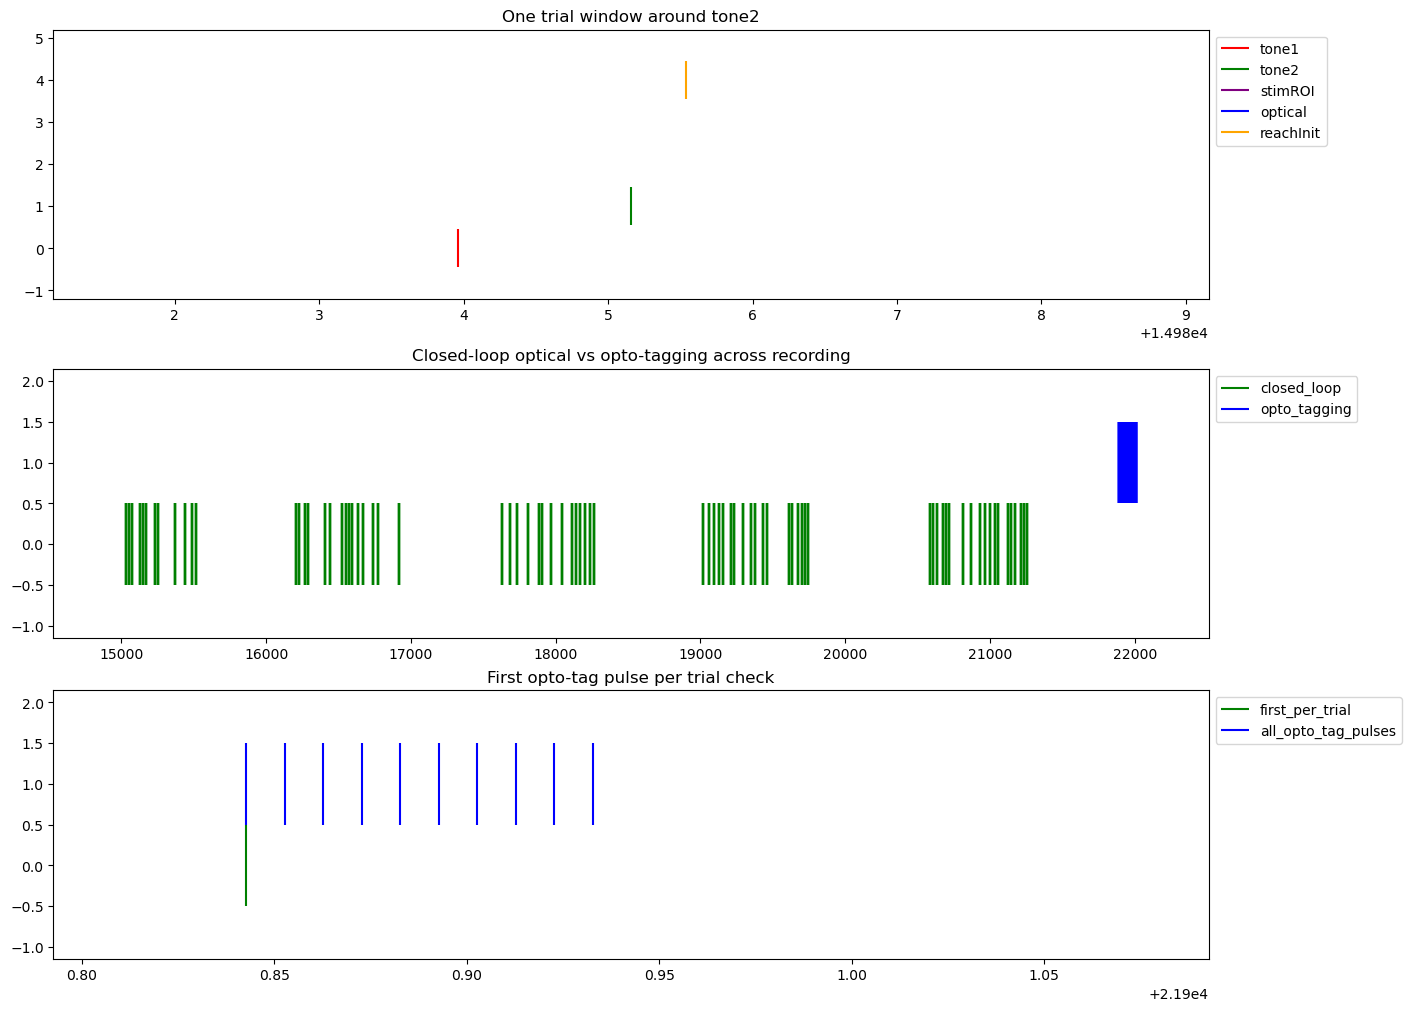

Plotting event times around tone2 for reach number: 21


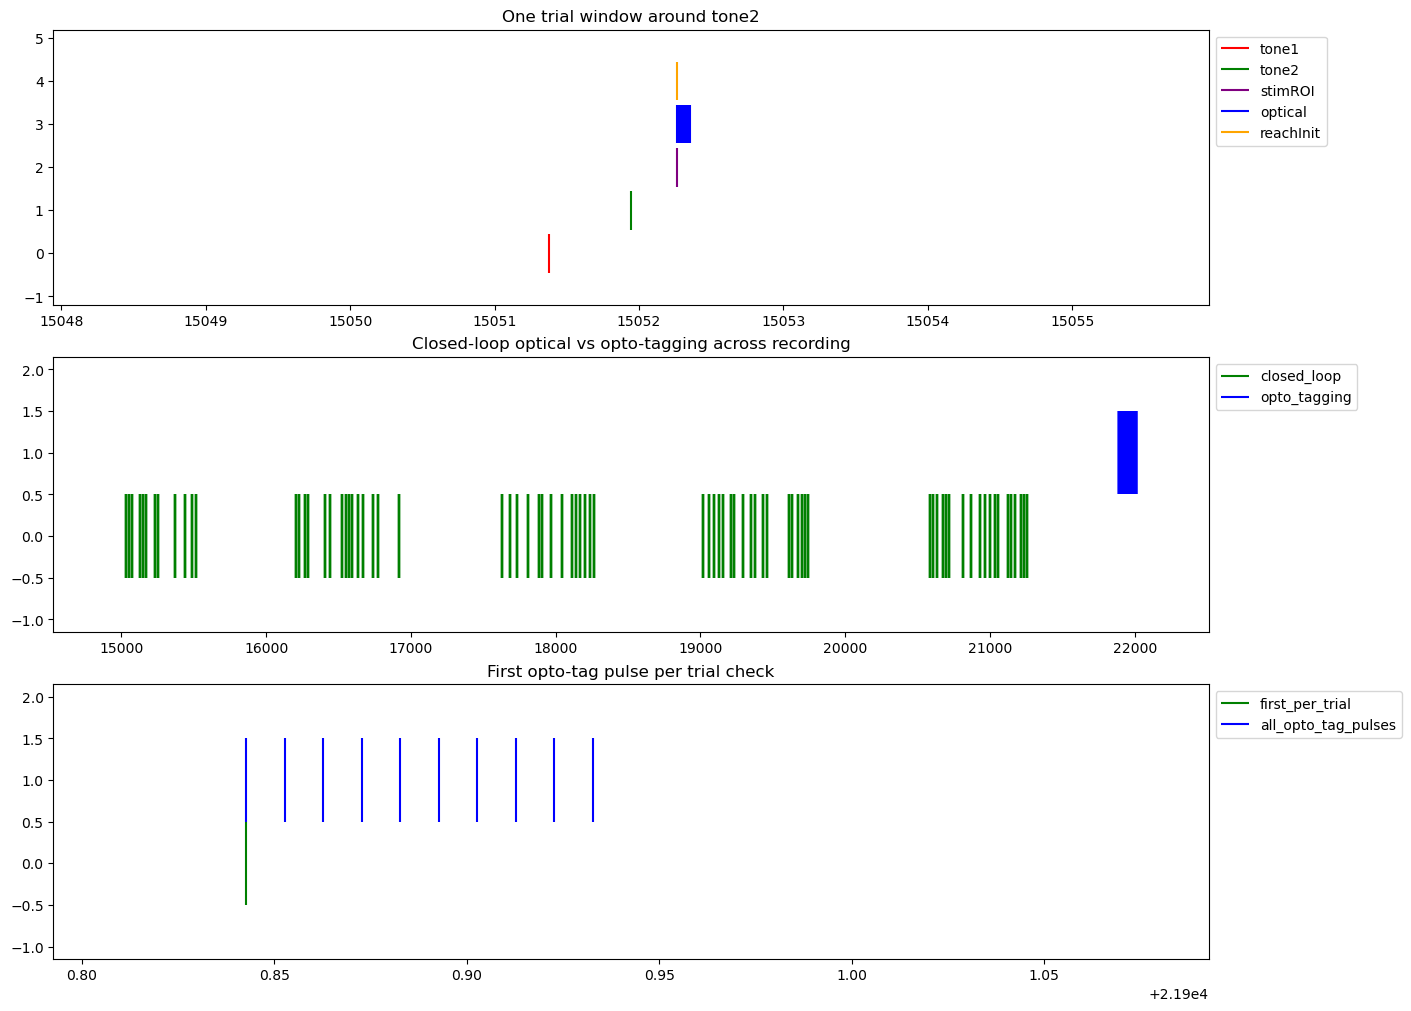

In [30]:

def plot_event_times_around_tone2(reach_number):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True)

    print(f"Plotting event times around tone2 for reach number: {reach_number}")
    axes[0].eventplot(
        [tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times],
        orientation='horizontal',
        colors=['r', 'green', 'purple', 'b', 'orange'],
        linelengths=0.9,
    )
    axes[0].set_xlim(tone2_start_times[reach_number] - 4, tone2_start_times[reach_number] + 4)
    axes[0].set_title('One trial window around tone2')
    axes[0].legend(['tone1', 'tone2', 'stimROI', 'optical', 'reachInit'], loc='upper left', bbox_to_anchor=(1, 1))

    axes[1].eventplot([opto_closed_loop_start_timestamps, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[1].set_xlim(opto_closed_loop_start_timestamps[0] - 500, opto_tag_start_timestamps[-1] + 500)
    axes[1].set_title('Closed-loop optical vs opto-tagging across recording')
    axes[1].legend(['closed_loop', 'opto_tagging'], loc='upper left', bbox_to_anchor=(1, 1))

    single_idx = min(40, len(opto_tag_start_timestamps) - 1)
    axes[2].eventplot([first_opto_tagging_timestamp_per_trial, opto_tag_start_timestamps], orientation='horizontal', colors=['g', 'b'])
    axes[2].set_xlim(opto_tag_start_timestamps[single_idx] - 0.05, opto_tag_start_timestamps[single_idx] + 0.25)
    axes[2].set_title('First opto-tag pulse per trial check')
    axes[2].legend(['first_per_trial', 'all_opto_tag_pulses'], loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()

reach_number = 19
plot_event_times_around_tone2(reach_number)

reach_number = 21
plot_event_times_around_tone2(reach_number)


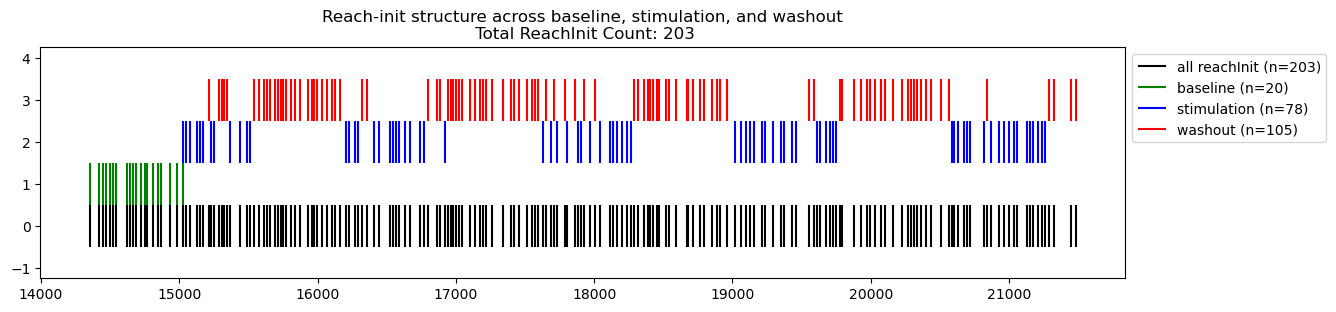

In [31]:
plt.figure(figsize=(14, 3))
plt.eventplot(
    [all_reach_Init_from_StimROI, reach_Init_baseline, reach_Init_from_StimROI_with_STIM, reach_Init_from_StimROI_without_STIM],
    orientation='horizontal',
    colors=['black', 'green', 'blue', 'red'],
)
plt.legend(['all reachInit (n={})'.format(len(all_reach_Init_from_StimROI)), 'baseline (n={})'.format(len(reach_Init_baseline)), 'stimulation (n={})'.format(len(reach_Init_from_StimROI_with_STIM)), 'washout (n={})'.format(len(reach_Init_from_StimROI_without_STIM))], loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Reach-init structure across baseline, stimulation, and washout\n Total ReachInit Count: {}'.format(len(all_reach_Init_from_StimROI)))
plt.show()